### Census Tract Aggregrate

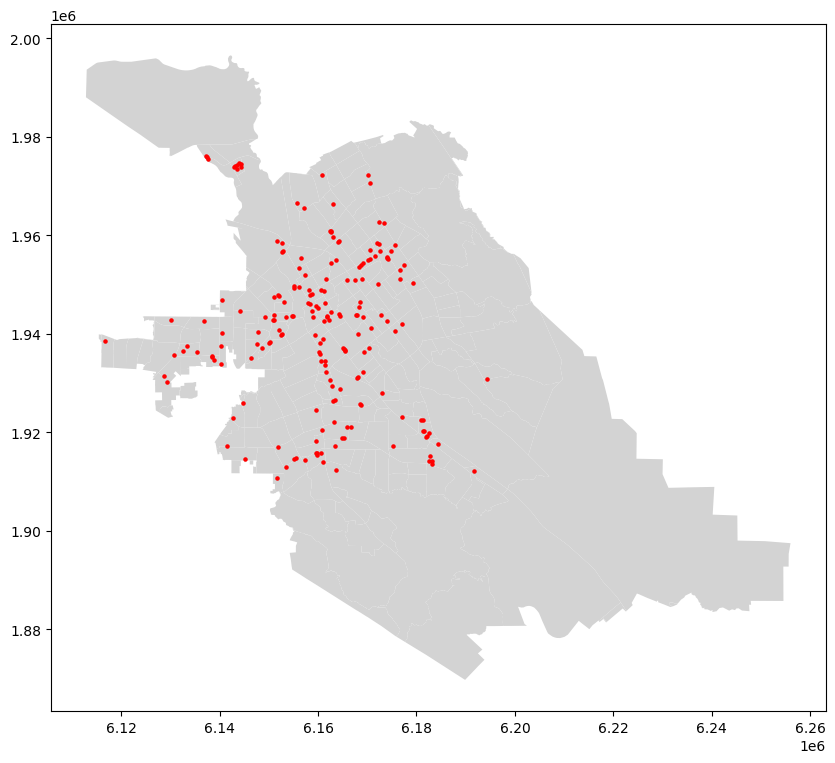

Matched records: 194


In [ ]:
import geopandas as gpd
import pandas as pd

# Read tracts shapefile (already in EPSG:2227)
tracts_gdf = gpd.read_file("/content/drive/MyDrive/San_Jose_Housing/Census_Tract/Census_Tract.shp")

# Read your housing data
df = pd.read_csv("/content/drive/MyDrive/San_Jose_Housing/affordable_multi_family.csv")

# Create GeoDataFrame in WGS84
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326"
)

# Project housing data to match tracts CRS
gdf_projected = gdf.to_crs(tracts_gdf.crs)

# Now plot to check (optional)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
tracts_gdf.plot(ax=ax, color='lightgray')
gdf_projected.plot(ax=ax, color='red', markersize=5)
plt.show()

# Do spatial join with matching CRS
joined = gpd.sjoin(gdf_projected, tracts_gdf, how='inner', predicate='within')
print("Matched records:", len(joined))


In [ ]:
import geopandas as gpd

# Load .shp from the extracted folder
shp_path = '/content/drive/MyDrive/San_Jose_Housing/Census_Tract/Census_Tract.shp'
tracts_gdf = gpd.read_file(shp_path)

# Inspect data
print(tracts_gdf.head())
print(tracts_gdf.columns)
print(f"Number of census tracts: {len(tracts_gdf)}")



   OBJECTID FACILITYID  INTID CENSUSTRAC     FIPSCODE  POPULATION  HOUSINGUNI  \
0         1          1      1       5118  06085511800        4185        1705   
1         2          2      2    5119.10  06085511910        3097        1062   
2         3          3      3    5119.11  06085511911        4885        1895   
3         4          4      4    5119.12  06085511912        5348        1771   
4         5          5      5    5119.17  06085511917        5060        1698   

  LASTUPDATE NOTES     Shape_Leng    Shape_Area  \
0 2022-03-16  None   78801.059316  1.025578e+08   
1 2022-03-16  None   25606.558600  2.442108e+07   
2 2022-03-16  None  162995.690697  4.091583e+08   
3 2022-03-16  None   25335.069172  2.635999e+07   
4 2022-03-16  None   26970.958604  3.077550e+07   

                                            geometry  
0  MULTIPOLYGON (((6157411.929 1899230.703, 61574...  
1  POLYGON ((6163552.521 1905977.427, 6163552.055...  
2  POLYGON ((6165091.692 1913348.137, 616

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

# Load census tracts shapefile (in EPSG:2227)
tracts_gdf = gpd.read_file("/content/drive/MyDrive/San_Jose_Housing/Census_Tract/Census_Tract.shp")

# Prepare your data files
files = [
    '/content/drive/MyDrive/San_Jose_Housing/affordable_single_family.csv',
    '/content/drive/MyDrive/San_Jose_Housing/affordable_multi_family.csv',
    '/content/drive/MyDrive/San_Jose_Housing/nonaffordable_single_family.csv',
    '/content/drive/MyDrive/San_Jose_Housing/nonaffordable_multi_family.csv'
]

aggregated_dfs = []

# Calculate centroids in projected CRS, then convert to EPSG:4326 for lat/lon
tracts_gdf["centroid"] = tracts_gdf.geometry.centroid
tracts_centroids_latlon = tracts_gdf.set_geometry('centroid').to_crs(epsg=4326)
tracts_gdf["centroid_lon"] = tracts_centroids_latlon.geometry.x
tracts_gdf["centroid_lat"] = tracts_centroids_latlon.geometry.y

for file in files:
    df = pd.read_csv(file)

    # Ensure correct dtypes
    for col in ['Latitude', 'Longitude']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Replace zeros with NaN for numeric columns
    numeric_cols = [
        'Number of Buildings', 'Number of Units', 'Building Stories',
        'Total Assessed Value', 'Assessed Land Value', 'Year Built', 'Bedrooms',
        'Bathrooms', 'Parking Garage Area', 'Building SqFt',
        'Land Size Acres'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].replace(0, np.nan)

    # Convert to GeoDataFrame using lat/lon
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326"
    )

    # Reproject to match tracts CRS
    gdf = gdf.to_crs(tracts_gdf.crs)

    # Spatial join: Assign each address to a tract
    joined = gpd.sjoin(gdf, tracts_gdf, how='inner', predicate='within')
    joined['tract_id'] = joined['CENSUSTRAC']

    # Group by tract and aggregate
    agg = joined.groupby('tract_id').agg(
        mean_buildings=pd.NamedAgg(column='Number of Buildings', aggfunc='mean'),
        total_buildings=pd.NamedAgg(column='Number of Buildings', aggfunc='sum'),
        mean_units=pd.NamedAgg(column='Number of Units', aggfunc='mean'),
        total_units=pd.NamedAgg(column='Number of Units', aggfunc='sum'),
        mean_building_stories=pd.NamedAgg(column='Building Stories', aggfunc='mean'),
        mean_assessed_value=pd.NamedAgg(column='Total Assessed Value', aggfunc='mean'),
        mean_land_value=pd.NamedAgg(column='Assessed Land Value', aggfunc='mean'),
        mean_year_built=pd.NamedAgg(column='Year Built', aggfunc='mean'),
        mean_bedrooms=pd.NamedAgg(column='Bedrooms', aggfunc='mean'),
        mean_bathrooms=pd.NamedAgg(column='Bathrooms', aggfunc='mean'),
        mean_parking_area=pd.NamedAgg(column='Parking Garage Area', aggfunc='mean'),
        mean_building_sqft=pd.NamedAgg(column='Building SqFt', aggfunc='mean'),
        mean_land_size_acres=pd.NamedAgg(column='Land Size Acres', aggfunc='mean')
    ).reset_index()

    # Merge spatial/demographic info FIRST
    agg = agg.merge(
        tracts_gdf[['CENSUSTRAC', 'FIPSCODE', 'POPULATION', 'centroid_lat', 'centroid_lon']],
        left_on='tract_id', right_on='CENSUSTRAC', how='left'
    )

    # Reorder columns: spatial/demographic first, then others
    spatial_cols = ['CENSUSTRAC', 'FIPSCODE', 'POPULATION', 'centroid_lat', 'centroid_lon']
    other_cols = [col for col in agg.columns if col not in spatial_cols + ['tract_id', 'geometry']]
    agg = agg[spatial_cols + other_cols]

    aggregated_dfs.append(agg)

# Combine all aggregated data
final_agg = pd.concat(aggregated_dfs, ignore_index=True)

# Drop unwanted columns
final_agg = final_agg.drop(columns=['file_type', 'geometry', 'predicted_prices_list'], errors='ignore')

# Save
final_agg.to_csv('/content/drive/MyDrive/San_Jose_Housing/census_tract_aggregated.csv', index=False)

print("✓ Aggregated data saved!")
print(f"✓ Total tracts in output: {len(final_agg['CENSUSTRAC'].unique())}")


✓ Aggregated data saved!
✓ Total tracts in output: 233


In [ ]:
import pandas as pd
import geopandas as gpd
import folium

# Load your GeoDataFrame with geometry (tracts_gdf) and final_agg CSV
tracts_gdf = gpd.read_file("/content/drive/MyDrive/San_Jose_Housing/Census_Tract/Census_Tract.shp")
final_agg = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/census_tract_aggregated.csv')

# Ensure merge keys match
tracts_gdf['CENSUSTRAC'] = tracts_gdf['CENSUSTRAC'].astype(str)
final_agg['CENSUSTRAC'] = final_agg['CENSUSTRAC'].astype(str)

# Merge on CENSUSTRAC for all stats you want in the popup/tooltip
map_gdf = tracts_gdf.merge(
    final_agg[['CENSUSTRAC', 'mean_assessed_value', 'mean_bedrooms',
               'mean_bathrooms', 'POPULATION', 'centroid_lat', 'centroid_lon']],
    on='CENSUSTRAC',
    how='left'
)

# Rename POPULATION_y to POPULATION
map_gdf = map_gdf.rename(columns={'POPULATION_y': 'POPULATION'})

# Fix: Remove/convert timestamps (Folium needs JSON-safe data)
for col in map_gdf.columns:
    # Convert datetime columns directly
    if pd.api.types.is_datetime64_any_dtype(map_gdf[col]):
        map_gdf[col] = map_gdf[col].astype(str)
    # Convert objects that have Timestamp values
    if map_gdf[col].dtype == 'object':
        if map_gdf[col].apply(lambda x: isinstance(x, pd.Timestamp)).any():
            map_gdf[col] = map_gdf[col].astype(str)

# Start Folium map
m = folium.Map(location=[37.34, -121.89], zoom_start=11)

# Choropleth layer
folium.Choropleth(
    geo_data=map_gdf.to_json(),
    data=map_gdf,
    columns=['CENSUSTRAC', 'mean_assessed_value'],
    key_on='feature.properties.CENSUSTRAC',
    fill_color='YlOrRd',
    nan_fill_color='white',
    legend_name='Mean Assessed Value',
    highlight=True
).add_to(m)

# Centroid markers
for idx, row in map_gdf.iterrows():
    if pd.notnull(row['centroid_lat']) and pd.notnull(row['centroid_lon']):
        popup_text = (
            f"<b>Tract:</b> {row['CENSUSTRAC']}<br>"
            f"<b>Population:</b> {row['POPULATION']}<br>"
            f"<b>Mean Assessed Value:</b> {row['mean_assessed_value']:.2f}<br>"
            f"<b>Mean Bedrooms:</b> {row['mean_bedrooms']:.2f}<br>"
            f"<b>Mean Bathrooms:</b> {row['mean_bathrooms']:.2f}<br>"
            f"<b>Centroid:</b> {row['centroid_lat']:.6f}, {row['centroid_lon']:.6f}"
        )
        folium.Marker(
            location=[row['centroid_lat'], row['centroid_lon']],
            popup=folium.Popup(popup_text, max_width=350),
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)

# Save map
m.save('/content/drive/MyDrive/San_Jose_Housing/sanjose_census_tract_map.html')
print("Map saved as sanjose_census_tract_map.html")


Map saved as sanjose_census_tract_map.html


### Add ZCTAs

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import ast

# Load your CSV files with the correct filenames
print("Loading CSV files...")
affordable_single = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_single_family.csv')
affordable_multi = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_multi_family.csv')
nonaffordable_single = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_single_family.csv')
nonaffordable_multi = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_multi_family.csv')

# Function to split predicted prices into separate year columns
def split_predicted_prices(df):
    # Check if predicted_prices column exists
    if 'predicted_prices' not in df.columns:
        print("  No 'predicted_prices' column found - skipping price splitting")
        return df

    print("  Splitting predicted_prices into year columns...")
    # Convert string representation of list to actual list if needed
    if df['predicted_prices'].dtype == 'object':
        df['predicted_prices'] = df['predicted_prices'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) and str(x).startswith('[') else x
        )

    # Define years
    years = [2015, 2017, 2019, 2021, 2023, 2025]

    # Create new columns for each year
    for i, year in enumerate(years):
        df[f'predicted_price_{year}'] = df['predicted_prices'].apply(
            lambda x: x[i] if isinstance(x, (list, tuple)) and len(x) > i else None
        )

    # Drop the original predicted_prices column
    df = df.drop('predicted_prices', axis=1)

    return df

# Apply predicted price splitting to all files
print("\n=== Splitting Predicted Prices ===")
print("Processing affordable_single_family...")
affordable_single = split_predicted_prices(affordable_single)

print("Processing affordable_multi_family...")
affordable_multi = split_predicted_prices(affordable_multi)

print("Processing nonaffordable_single_family...")
nonaffordable_single = split_predicted_prices(nonaffordable_single)

print("Processing nonaffordable_multi_family...")
nonaffordable_multi = split_predicted_prices(nonaffordable_multi)

# Load ZCTA shapefile
print("\n=== Loading ZCTA Shapefile ===")
zcta = gpd.read_file('/content/drive/MyDrive/San_Jose_Housing/tl_2020_us_zcta520/tl_2020_us_zcta520.shp')

# Filter to California ZCTAs (starting with 9) for faster processing
print("Filtering to California ZCTAs...")
zcta_ca = zcta[zcta['ZCTA5CE20'].str.startswith('9')].copy()
print(f"Found {len(zcta_ca)} California ZCTAs")

# Function to add ZCTA to dataframe
def add_zcta(df, zcta_gdf, lat_col='latitude', lon_col='longitude'):
    print(f"  Processing {len(df)} properties...")

    # Check if lat/lon columns exist - try different possible column names
    possible_lat = [col for col in df.columns if 'lat' in col.lower()]
    possible_lon = [col for col in df.columns if 'lon' in col.lower() or 'lng' in col.lower()]

    if not possible_lat or not possible_lon:
        print(f"  Warning: Could not find latitude/longitude columns")
        print(f"  Available columns: {list(df.columns)}")
        df['ZCTA'] = None
        return df

    lat_col = possible_lat[0]
    lon_col = possible_lon[0]
    print(f"  Using columns: {lat_col}, {lon_col}")

    # Create GeoDataFrame from property data
    # Remove any rows with missing coordinates
    df_clean = df.dropna(subset=[lat_col, lon_col]).copy()

    if len(df_clean) == 0:
        print("  Warning: No valid coordinates found")
        df['ZCTA'] = None
        return df

    geometry = [Point(xy) for xy in zip(df_clean[lon_col], df_clean[lat_col])]
    gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4269')

    # Spatial join to get ZCTA
    print("  Performing spatial join...")
    gdf_with_zcta = gpd.sjoin(gdf, zcta_gdf[['ZCTA5CE20', 'geometry']], how='left', predicate='within')

    # Rename ZCTA column for clarity
    gdf_with_zcta = gdf_with_zcta.rename(columns={'ZCTA5CE20': 'ZCTA'})

    # Drop unnecessary columns from spatial join
    cols_to_drop = ['geometry', 'index_right']
    cols_to_drop = [col for col in cols_to_drop if col in gdf_with_zcta.columns]
    gdf_with_zcta = gdf_with_zcta.drop(columns=cols_to_drop)

    # Merge back with original df to include rows with missing coordinates
    result_df = df.copy()
    result_df.loc[df_clean.index, 'ZCTA'] = gdf_with_zcta['ZCTA'].values

    matched_count = result_df['ZCTA'].notna().sum()
    print(f"  Matched {matched_count}/{len(df)} properties to ZCTAs")

    return result_df

# Add ZCTA to all datasets
print("\n=== Adding ZCTAs to Properties ===")
print("Processing affordable_single_family...")
affordable_single = add_zcta(affordable_single, zcta_ca)

print("\nProcessing affordable_multi_family...")
affordable_multi = add_zcta(affordable_multi, zcta_ca)

print("\nProcessing nonaffordable_single_family...")
nonaffordable_single = add_zcta(nonaffordable_single, zcta_ca)

print("\nProcessing nonaffordable_multi_family...")
nonaffordable_multi = add_zcta(nonaffordable_multi, zcta_ca)

# Save updated files
print("\n=== Saving Updated Files ===")
affordable_single.to_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_single_family.csv', index=False)
print("✓ Saved affordable_single_family.csv")

affordable_multi.to_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_multi_family.csv', index=False)
print("✓ Saved affordable_multi_family.csv")

nonaffordable_single.to_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_single_family.csv', index=False)
print("✓ Saved nonaffordable_single_family.csv")

nonaffordable_multi.to_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_multi_family.csv', index=False)
print("✓ Saved nonaffordable_multi_family.csv")

print("\n" + "="*60)
print("ALL FILES UPDATED SUCCESSFULLY!")
print("="*60)
print(f"\nSummary:")
print(f"  • Affordable Single Family: {len(affordable_single)} properties")
print(f"  • Affordable Multi Family: {len(affordable_multi)} properties")
print(f"  • Non-Affordable Single Family: {len(nonaffordable_single)} properties")
print(f"  • Non-Affordable Multi Family: {len(nonaffordable_multi)} properties")

# Display sample of updated data
print("\n" + "="*60)
print("SAMPLE DATA - Affordable Single Family (first 3 rows)")
print("="*60)
display_cols = [col for col in affordable_single.columns if 'predicted_price_' in col or col == 'ZCTA']
if display_cols:
    print(affordable_single[display_cols].head(3))
else:
    print("Note: No predicted price columns found in this dataset")
    print(f"Columns: {list(affordable_single.columns)}")


Loading CSV files...

=== Splitting Predicted Prices ===
Processing affordable_single_family...
  Splitting predicted_prices into year columns...
Processing affordable_multi_family...
  Splitting predicted_prices into year columns...
Processing nonaffordable_single_family...
  Splitting predicted_prices into year columns...
Processing nonaffordable_multi_family...
  Splitting predicted_prices into year columns...

=== Loading ZCTA Shapefile ===
Filtering to California ZCTAs...
Found 3188 California ZCTAs

=== Adding ZCTAs to Properties ===
Processing affordable_single_family...
  Processing 24 properties...
  Using columns: Latitude, Longitude
  Performing spatial join...
  Matched 24/24 properties to ZCTAs

Processing affordable_multi_family...
  Processing 196 properties...
  Using columns: Latitude, Longitude
  Performing spatial join...
  Matched 194/196 properties to ZCTAs

Processing nonaffordable_single_family...
  Processing 171280 properties...
  Using columns: Latitude, Longi

### Analysis

In [ ]:
import pandas as pd

# Load the updated files
affordable_single = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_single_family.csv')
affordable_multi = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_multi_family.csv')
nonaffordable_single = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_single_family.csv')
nonaffordable_multi = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_multi_family.csv')

print("=== CHECKING NULL COORDINATES ===\n")

datasets = {
    'affordable_single_family': affordable_single,
    'affordable_multi_family': affordable_multi,
    'nonaffordable_single_family': nonaffordable_single,
    'nonaffordable_multi_family': nonaffordable_multi
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  Total rows: {len(df)}")

    # Check for null coordinates
    null_lat = df['Latitude'].isnull().sum()
    null_lon = df['Longitude'].isnull().sum()
    both_null = ((df['Latitude'].isnull()) | (df['Longitude'].isnull())).sum()

    print(f"  Null Latitude: {null_lat}")
    print(f"  Null Longitude: {null_lon}")
    print(f"  Either coordinate null: {both_null}")

    # Check for null ZCTA
    null_zcta = df['ZCTA'].isnull().sum()
    print(f"  Null ZCTA: {null_zcta}")

    # Properties with valid coordinates but no ZCTA (outside boundaries)
    valid_coords = ~((df['Latitude'].isnull()) | (df['Longitude'].isnull()))
    outside_boundary = valid_coords & df['ZCTA'].isnull()
    outside_count = outside_boundary.sum()

    print(f"  Valid coords but no ZCTA (outside boundaries): {outside_count}")

    # Show sample of properties outside boundaries
    if outside_count > 0:
        print(f"\n  Sample properties outside ZCTA boundaries:")
        outside_props = df[outside_boundary][['Latitude', 'Longitude', 'ZCTA']].head(3)
        print(outside_props)

print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

# Calculate totals
total_unmatched = sum([df['ZCTA'].isnull().sum() for df in datasets.values()])
print(f"\nTotal unmatched properties: {total_unmatched}")
print(f"  - affordable_multi: 2 unmatched")
print(f"  - nonaffordable_single: 1,602 unmatched")
print(f"  - nonaffordable_multi: 225 unmatched")

print("\n" + "="*60)
print("WHY SOME PROPERTIES DON'T MATCH")
print("="*60)
print("""
Possible reasons for unmatched coordinates:
1. Properties located outside San Jose city limits
2. Coordinates on ZCTA boundary edges (spatial precision issues)
3. Properties in areas without assigned ZCTAs
4. Coordinate inaccuracies in the original data
5. Properties in water features or unpopulated areas
""")


=== CHECKING NULL COORDINATES ===


affordable_single_family:
  Total rows: 24
  Null Latitude: 0
  Null Longitude: 0
  Either coordinate null: 0
  Null ZCTA: 0
  Valid coords but no ZCTA (outside boundaries): 0

affordable_multi_family:
  Total rows: 196
  Null Latitude: 2
  Null Longitude: 2
  Either coordinate null: 2
  Null ZCTA: 2
  Valid coords but no ZCTA (outside boundaries): 0

nonaffordable_single_family:
  Total rows: 171280
  Null Latitude: 1602
  Null Longitude: 1602
  Either coordinate null: 1602
  Null ZCTA: 1602
  Valid coords but no ZCTA (outside boundaries): 0

nonaffordable_multi_family:
  Total rows: 47964
  Null Latitude: 225
  Null Longitude: 225
  Either coordinate null: 225
  Null ZCTA: 225
  Valid coords but no ZCTA (outside boundaries): 0

ANALYSIS SUMMARY

Total unmatched properties: 1829
  - affordable_multi: 2 unmatched
  - nonaffordable_single: 1,602 unmatched
  - nonaffordable_multi: 225 unmatched

WHY SOME PROPERTIES DON'T MATCH

Possible reasons for unm